# TP04 MapReduce - Multiplication Matricielle
# Matrice A et B complètes

## Chargement des matrices A et B

In [18]:
import numpy as np
import time
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
from numba import njit

In [19]:
A = np.load("A.npy")
B = np.load("B.npy")

# Affichage des dimensions pour vérification
print(f"Matrice A : {A.shape}")
print(f"Matrice B : {B.shape}")

Matrice A : (100, 10000)
Matrice B : (10000, 100)


In [34]:
C_numpy = A @ B

## Questions

1. Ecrire un algorithme MapReduce qui calcule le produit matriciel de A et B en **multithreading** dans lequel chaque worker réalise le calcul d’un ou plusieurs $c_{ij}$

In [21]:
def compute_element(args):
    """ Calcule un élément c_ij du produit matriciel C = A * B """
    A, B, i, j = args
    return i, j, sum(A[i, k] * B[k, j] for k in range(A.shape[1]))

def Produit_mt(A, B, num_workers=4):
    C = np.zeros((A.shape[0], B.shape[1]))
    tasks = [(A, B, i, j) for i in range(A.shape[0]) for j in range(B.shape[1])]
    
    tic = time.time()
    with ThreadPoolExecutor(max_workers=num_workers) as t_exe:
        results = t_exe.map(compute_element, tasks)
    toc = time.time()
    
    for i, j, value in results:
        C[i, j] = value
    
    return C, toc - tic


In [20]:
%time C_mt, _ = Produit_mt(A,B)

CPU times: user 28.3 s, sys: 130 ms, total: 28.4 s
Wall time: 28.3 s


2. Ecrire un algorithme MapReduce qui calcule le produit matriciel de A et B en **mutiprocessing** dans lequel chaque worker réalise le calcul d’un ou plusieurs $c_{ij}$

In [22]:
def Produit_mp(A, B, num_workers=4):
    C = np.zeros((A.shape[0], B.shape[1]))
    tasks = [(A, B, i, j) for i in range(A.shape[0]) for j in range(B.shape[1])]
    
    tic = time.time()
    with ProcessPoolExecutor(max_workers=num_workers) as p_exe:
        results = p_exe.map(compute_element, tasks)
    toc = time.time()
    
    for i, j, value in results:
        C[i, j] = value
    
    return C, toc - tic

In [11]:
%time C_mp, _ = Produit_mp(A,B)

CPU times: user 36.9 s, sys: 2min 15s, total: 2min 51s
Wall time: 4min 34s


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Nous pouvons observer une différence significative entre le temps total CPU et le Wall Time. Cela signifie qu'il y a une quantité considérable de temps d'inactivité, incluant l'attente des processus, les changements de contexte et la communication entre processus dans le multiprocessing.
  </p>
</div>

3.Comparer les temps de restitution des différentes implémentations en variant le nombre de workers.

In [ ]:
def measure_time(function, A, B):
    """ Calcule les temps de restitution pour plusieurs nombres de workers"""
    worker_counts = [1, 2, 4, 8, 16]
    times = []

    for num_workers in worker_counts:
        _, duration = function(A, B, num_workers)
        times.append(duration)

    return times

In [27]:
mp_times = measure_time(Produit_mp, A, B)
mt_times = measure_time(Produit_mt, A, B)

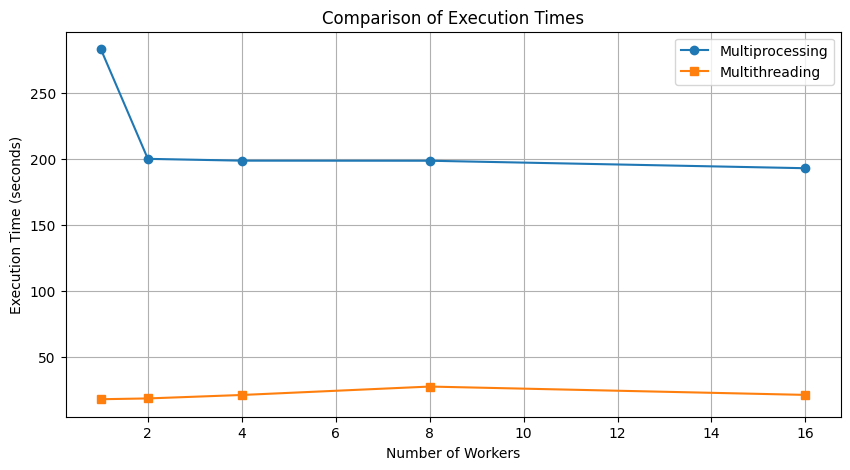

In [28]:
worker_counts = [1, 2, 4, 8, 16]
plt.figure(figsize=(10, 5))
plt.plot(worker_counts, mp_times, label='Multiprocessing', marker='o')
plt.plot(worker_counts, mt_times, label='Multithreading', marker='s')
plt.xlabel('Number of Workers')
plt.ylabel('Execution Time (seconds)')
plt.title('Comparison of Execution Times')
plt.legend()
plt.grid()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Dans le cas du multiprocessing, nous constatons que l'augmentation du nombre de workers de 1 à 2 a amélioré le temps d'exécution. Cependant, pour un nombre plus élevé de workers, il n'y a pas eu d'amélioration significative du temps d'exécution, ce qui peut indiquer que le gain de performance est limité par le temps nécessaire pour créer et synchroniser les processus.
  </p>
  <p>
    En ce qui concerne le multithreading, le temps d'exécution a augmenté avec plus de workers, ce qui pourrait être dû au GIL, qui limite l'utilisation à un seul thread à la fois. Nous pouvons tester la suppression de l'effet du GIL pour évaluer son impact.
  </p>
</div>

In [29]:
@njit(nogil=True)
def compute_element_nogil(A, B, i, j):
    """ Calcule un élément c_ij du produit matriciel C = A * B """
    value = 0.0
    for k in range(A.shape[1]):
        value += A[i, k] * B[k, j]
    return i, j, value

def Produit_nogil(A, B, num_workers=4):
    C = np.zeros((A.shape[0], B.shape[1]))
    tasks = [(A, B, i, j) for i in range(A.shape[0]) for j in range(B.shape[1])]
    
    tic = time.time()
    with ThreadPoolExecutor(max_workers=num_workers) as t_exe:
        results = t_exe.map(lambda args: compute_element_nogil(*args), tasks)
    toc = time.time()
    
    for i, j, value in results:
        C[i, j] = value
    
    return C, toc - tic


A_first = np.random.rand(2, 2)
B_first = np.random.rand(2, 2)

C_first = Produit_nogil(A_first, B_first)


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    La fonction a été compilée une première fois afin d'éviter d'ajouter le temps de création de la fonction C dans les analyses futures.
  </p>
</div>

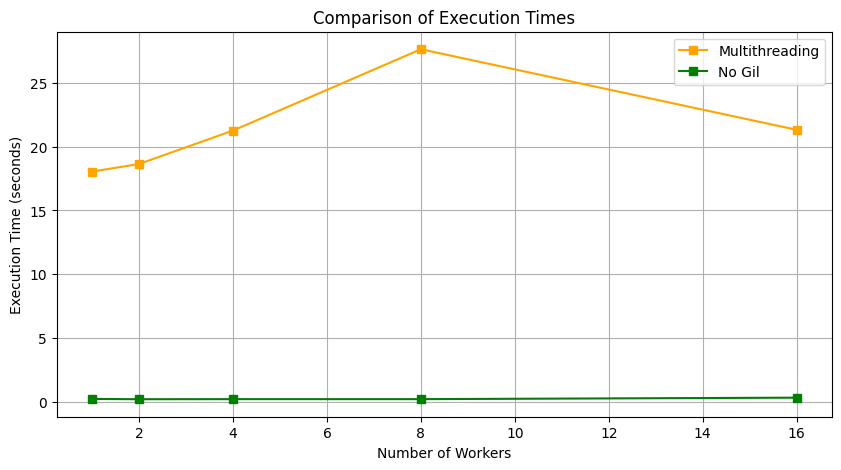

In [35]:
nogil_times = mp_times = measure_time(Produit_nogil, A, B)

plt.figure(figsize=(10, 5))
plt.plot(worker_counts, mt_times, label='Multithreading', marker='s', color = "orange")
plt.plot(worker_counts, nogil_times, label='No Gil', marker='s', color = "green")
plt.xlabel('Number of Workers')
plt.ylabel('Execution Time (seconds)')
plt.title('Comparison of Execution Times')
plt.legend()
plt.grid()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Comme nous pouvons l'observer, la suppression du GIL, en plus de l'effet de njit, a considérablement amélioré l'efficacité de la fonction.
  </p>
</div>

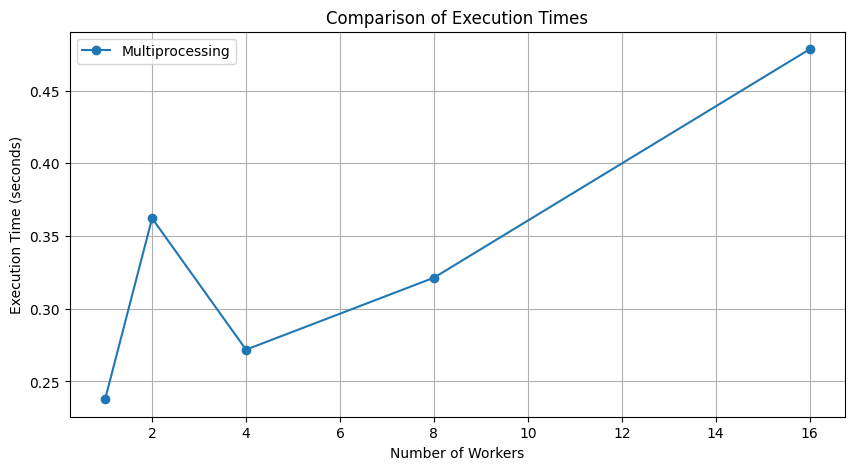

In [39]:
A_small = np.random.rand(50, 50)
B_small = np.random.rand(50, 50)

small_times = measure_time(Produit_mp, A_small, B_small)

plt.figure(figsize=(10, 5))
plt.plot(worker_counts, small_times, label='Multiprocessing', marker='o')
plt.xlabel('Number of Workers')
plt.ylabel('Execution Time (seconds)')
plt.title('Comparison of Execution Times')
plt.legend()
plt.grid()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For a smaller matrix the execution time increases a lot with the number of processes. This may shows clearly that creating multiple processes has a high overhead cost. Therefore, the coordination cost may be higher than the benefit of parallelism for small matrices.
  </p>
</div>